In [3]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [4]:
npzfile = np.load("/content/drive/MyDrive/Colab - Khanh/Data/toy_data_two_moon.npz")

In [5]:
x_train = torch.FloatTensor(npzfile['arr_0'])
y_train = torch.FloatTensor(npzfile['arr_2'])

# Test inputs and target outputs
x_test = torch.FloatTensor(npzfile['arr_1'])
y_test = torch.FloatTensor(npzfile['arr_3'])

Text(0.5, 1.0, 'Test data')

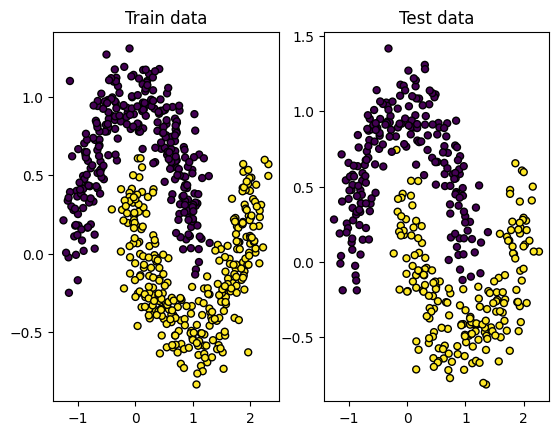

In [6]:
plt.subplot(121);
plt.scatter(x_train[:, 0], x_train[:, 1], marker='o', c=y_train[:,0], s=25, edgecolor='k');
plt.title("Train data")
plt.subplot(122);
plt.scatter(x_test[:, 0], x_test[:, 1], marker='o', c=y_test[:,0], s=25, edgecolor='k');
plt.title("Test data")

In [7]:
logistic_linear = nn.Linear(2,1)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(logistic_linear.parameters(), lr=0.01)

In [8]:
max_epoch = 100

loss_logs = []
acc_logs = []
for epoch in range(max_epoch):
  with torch.no_grad():
    y_pred = logistic_linear(x_test)
    class_pred = (y_pred>0).float()
    acc_logs.append(float(sum(class_pred==y_test))/float(y_test.shape[0]))
  #Tính trên train
  y_train_pred = logistic_linear(x_train)
  loss_train = loss_fn(y_train_pred, y_train)
  #Reset gradient->backward->cập nhật
  optimizer.zero_grad()
  loss_train.backward()
  optimizer.step()

  loss_logs.append(loss_train.item())

print('Accuracy of model', acc_logs[-1]*100)

Accuracy of model 73.0


/tmp/ipython-input-507/935336348.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
/tmp/ipython-input-507/935336348.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  np.arange(y_min, y_max, 0.02))


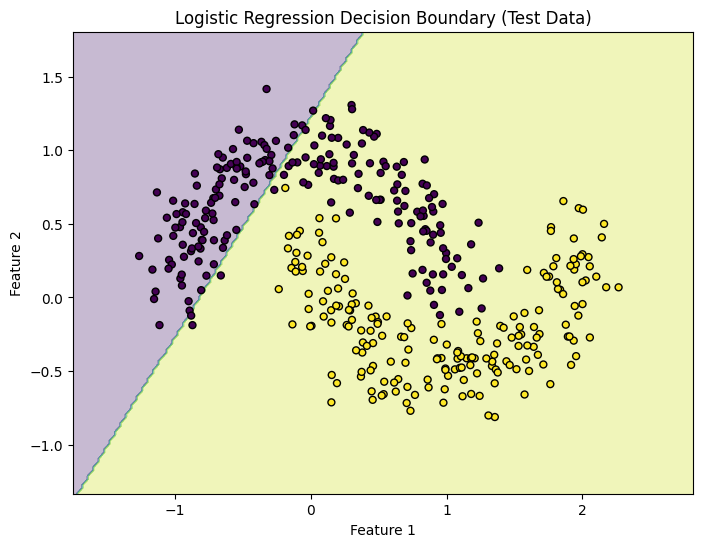

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo một lưới điểm (meshgrid) bao phủ không gian dữ liệu
x_min, x_max = x_train[:, 0].min() - 0.5, x_train[:, 0].max() + 0.5
y_min, y_max = x_train[:, 1].min() - 0.5, x_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 2. Đưa lưới điểm này vào mô hình để dự đoán
# Gộp tọa độ x và y lại thành tensor
grid_points = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

with torch.no_grad():
    y_grid_pred = logistic_linear(grid_points)
    # Nếu logit > 0 thì là class 1, ngược lại là 0
    class_grid_pred = (y_grid_pred > 0).float().numpy()

# 3. Reshape lại để vẽ contour
Z = class_grid_pred.reshape(xx.shape)

# 4. Vẽ biểu đồ
plt.figure(figsize=(8, 6))

# Vẽ vùng quyết định (background)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis') # Bạn có thể đổi 'viridis' thành 'coolwarm' hoặc 'bwr'

# Vẽ đè các điểm dữ liệu thật (tập test) lên trên
plt.scatter(x_test[:, 0], x_test[:, 1], c=y_test[:, 0], marker='o', s=25, edgecolor='k', cmap='viridis')

plt.title("Logistic Regression Decision Boundary (Test Data)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()